# Модуль 7. Регуляризация градиентного бустинга

**Интерактивная версия:** `lessons/lesson_7/web/index.html`

Рычаги регуляризации по очереди: как меняются кривые валидации. Выводы проверяем на 5 разбиениях.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gbcourse import datasets, GBRegressor
from gbcourse.plotting import use_course_style

use_course_style()

In [2]:
X, y = datasets.regression_1d(kind="wave", n=400, noise=0.6, seed=71)
configs = {
    "свободная (ν=1, глубина 6)": dict(learning_rate=1.0, max_depth=6),
    "+ маленький темп": dict(learning_rate=0.05, max_depth=6),
    "+ неглубокие деревья": dict(learning_rate=0.05, max_depth=2),
    "+ подвыборка 0.5": dict(learning_rate=0.05, max_depth=2, subsample=0.5, seed=1),
    "+ min_samples_leaf 10": dict(learning_rate=0.05, max_depth=2, subsample=0.5, seed=1, min_samples_leaf=10),
}
rows, curves = [], {}
for name, kw in configs.items():
    best = []
    for split in range(5):
        a, b, c, d = datasets.train_test_split(X, y, test_size=0.3, seed=split)
        m = GBRegressor(n_estimators=400, **kw).fit(a, c, eval_set=(b, d))
        best.append(min(m.history_["eval"]))
        if split == 0:
            curves[name] = m.history_["eval"]
    rows.append({"конфигурация": name, "лучшая ½MSE (среднее)": np.mean(best), "± std": np.std(best)})
pd.DataFrame(rows).round(4)

,конфигурация,лучшая ½MSE (среднее),± std
0,"свободная (ν=1, глубина 6)",0.2408,0.0327
1,+ маленький темп,0.2191,0.0291
2,+ неглубокие деревья,0.1811,0.0220
3,+ подвыборка 0.5,0.1770,0.0201
4,+ min_samples_leaf 10,0.1777,0.0216


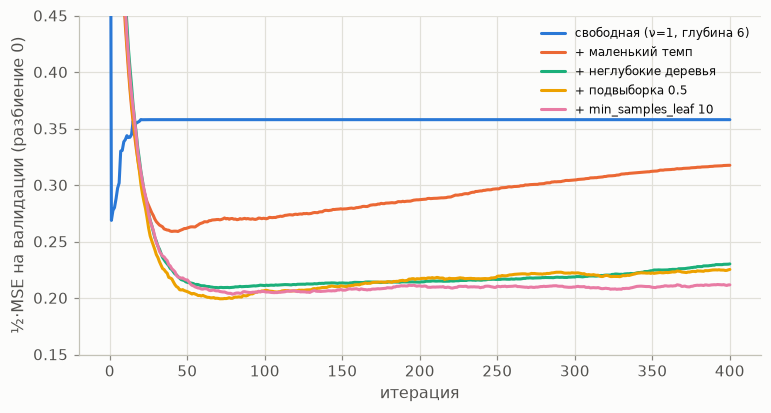

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
for name, c in curves.items():
    ax.plot(c, label=name)
ax.set(xlabel="итерация", ylabel="½·MSE на валидации (разбиение 0)", ylim=(0.15, 0.45))
ax.legend(fontsize=8)
plt.show()

## Упражнения

1. Какой рычаг дал наибольший прирост? Попробуйте изменить порядок включения.

Решения: `python lessons/lesson_7/exercises/solutions.py`.